In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('instructor_effectiveness_dataset_2000_rows.csv.csv')
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [5]:
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [8]:
df.shape

(2000, 12)

In [15]:
df.columns.tolist()

['batch_id',
 'instructor_id',
 'course_id',
 'completion_rate',
 'avg_score_improvement',
 'avg_quiz_score',
 'dropout_rate',
 'avg_watch_time',
 'assignment_submission_rate',
 'forum_activity_rate',
 'avg_feedback_score',
 'feedback_response_rate']

In [7]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [17]:
df.info() # there is no null values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


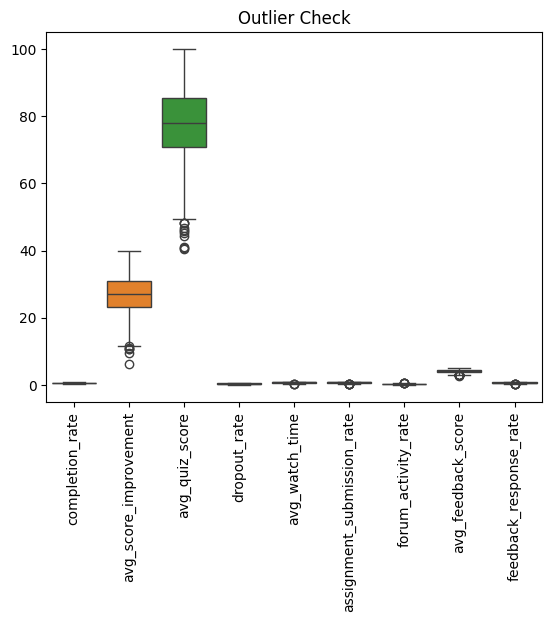

In [18]:
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.title('Outlier Check')
plt.show()

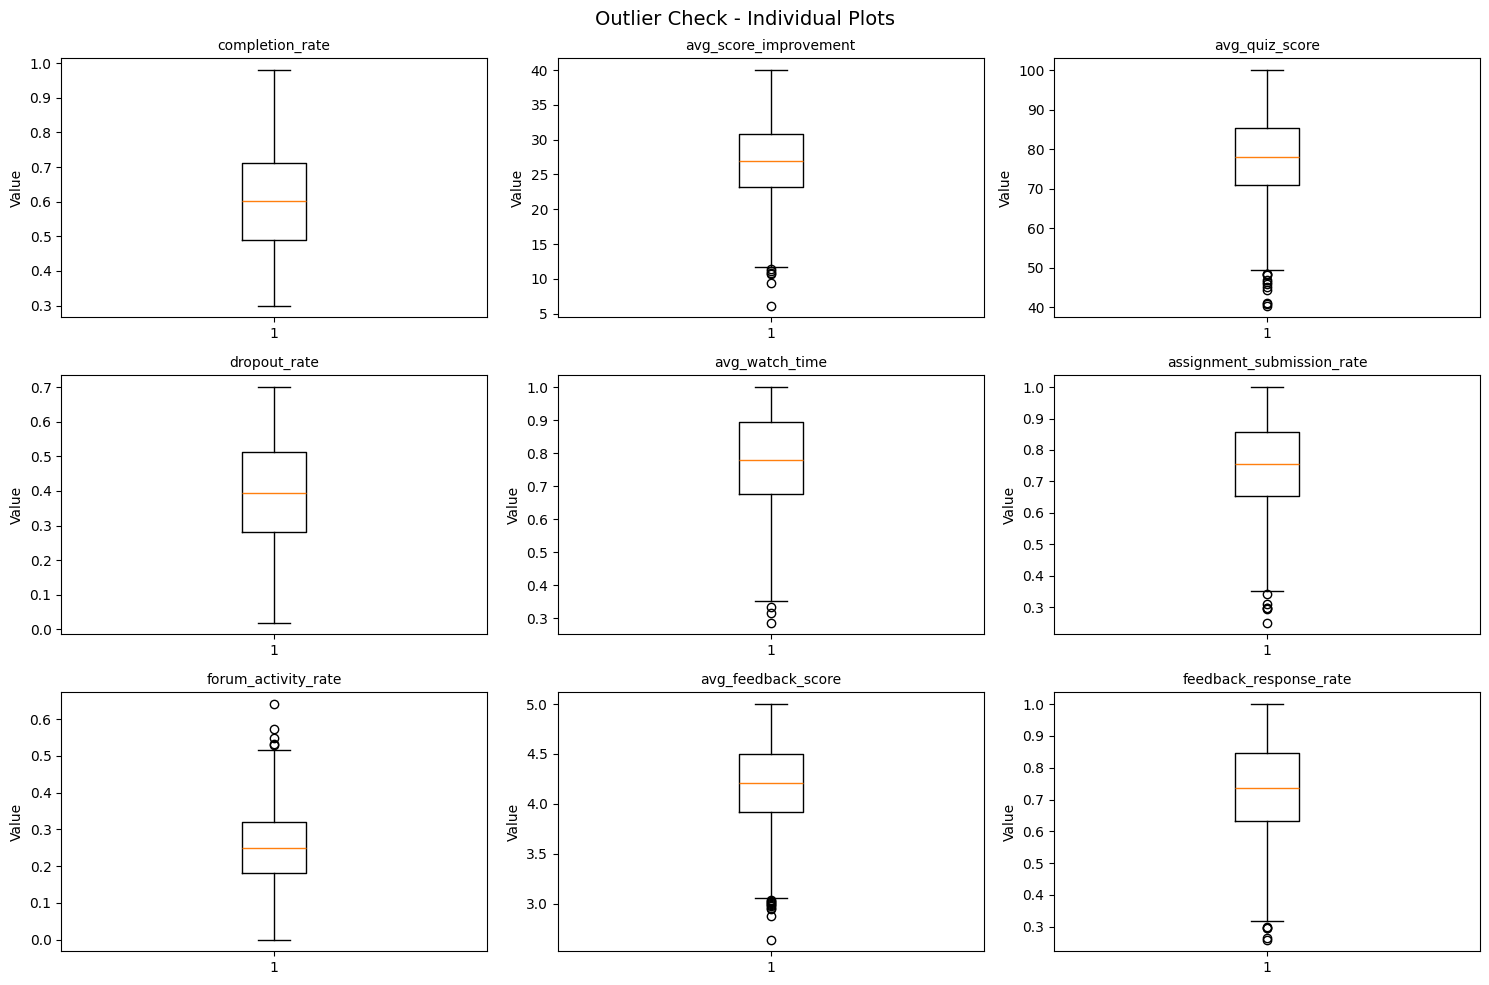

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

numeric_cols = df.select_dtypes(include='number').columns

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Check - Individual Plots', fontsize=14)
plt.tight_layout()
plt.show()

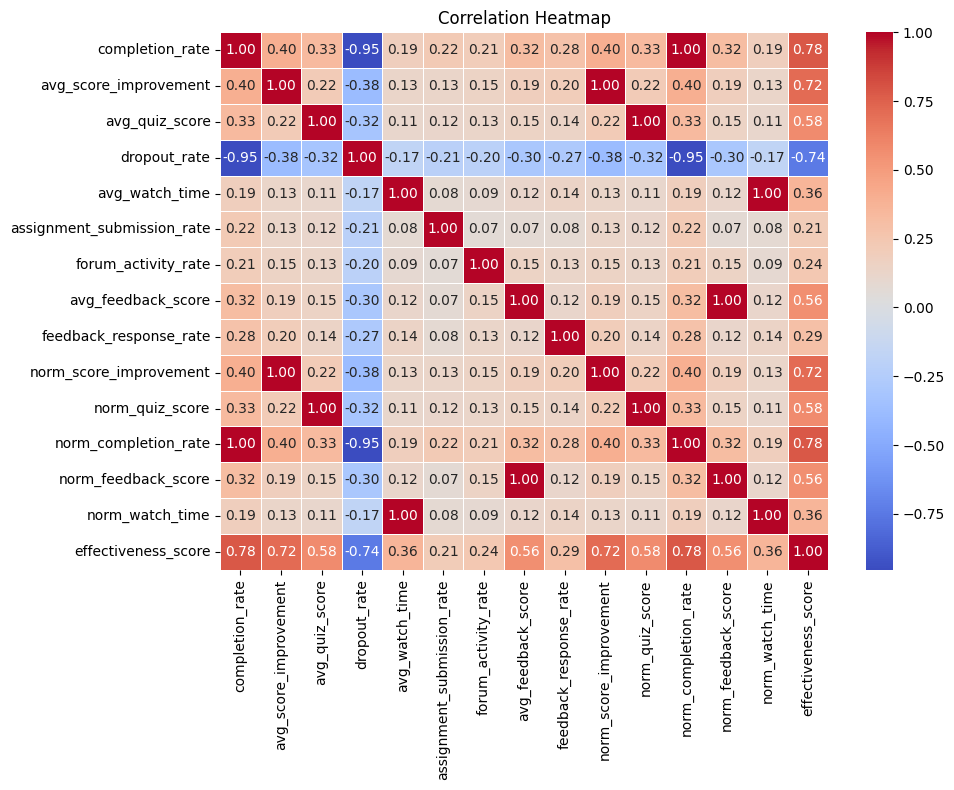

In [45]:
# Step 5 - Correlation Heatmap
plt.figure(figsize=(10, 8))  

# corr() - The relationship of each column with the other columns comes out.
# annot=True -> values appearance in each box
# cmap='coolwarm' -> red means positive, blue means negative relation
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True,         
            fmt='.2f',         
            cmap='coolwarm',    
            linewidths=0.5)     
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [27]:
# low completion's rate top 5 batches
df[['batch_id', 'instructor_id', 'completion_rate']].sort_values('completion_rate').head(5)

,batch_id,instructor_id,completion_rate
1478,B_1082,I_075,0.3
1240,B_0373,I_038,0.3
682,B_0706,I_075,0.3
1999,B_1127,I_045,0.3
1838,B_1752,I_070,0.3


In [31]:
# Normalizer

def min_max_normalize(x):
    return (x - x.min()) / (x.max() - x.min())

In [32]:
df['norm_score_improvement'] = min_max_normalize(df['avg_score_improvement'])
df['norm_quiz_score']        = min_max_normalize(df['avg_quiz_score'])
df['norm_completion_rate']   = min_max_normalize(df['completion_rate'])
df['norm_feedback_score']    = min_max_normalize(df['avg_feedback_score'])
df['norm_watch_time']        = min_max_normalize(df['avg_watch_time'])

In [49]:
df['effectiveness_score'] = (0.30 * df['norm_score_improvement'] + 
                             0.20 * df['norm_quiz_score'] +
                             0.20 * df['norm_completion_rate']   + 
                             0.20 * df['norm_feedback_score']    +
                             0.10 * df['norm_watch_time']
) 

In [50]:
df['effectiveness_score'].describe() # Batch summary

count    2000.000000
mean        0.601624
std         0.121064
min         0.194679
25%         0.522571
50%         0.602343
75%         0.681964
max         0.983475
Name: effectiveness_score, dtype: float64

In [77]:
df['effectiveness_score']

0       0.346571
1       0.606220
2       0.390710
3       0.669269
4       0.725548
          ...   
1995    0.443390
1996    0.941049
1997    0.602339
1998    0.545973
1999    0.495881
Name: effectiveness_score, Length: 2000, dtype: float64

In [64]:
t33 = df['effectiveness_score'].quantile(0.33)
t67 = df['effectiveness_score'].quantile(0.67)

print(f"Low cutoff : {t33:.3f}")
print(f"High cutoff : {t67:.3f}")

Low cutoff : 0.552
High cutoff : 0.656


In [65]:
def assign_tier(score):
    if score <= t33:
        return 'Low'
    elif score <= t67:
        return 'Medium'
    else:
        return 'High'

df['effectiveness_tier'] = df['effectiveness_score'].apply(assign_tier)

df['effectiveness_tier'].value_counts()

effectiveness_tier
Medium    680
Low       660
High      660
Name: count, dtype: int64

In [66]:
df['effectiveness_tier'] = df['effectiveness_score'].apply(assign_tier)

df['effectiveness_tier'].value_counts()

effectiveness_tier
Medium    680
Low       660
High      660
Name: count, dtype: int64

In [70]:

instructor_df = df.groupby('instructor_id').agg(
    completion_rate      = ('completion_rate', 'mean'),
    avg_score_improvement    = ('avg_score_improvement', 'mean'),
    avg_quiz_score            = ('avg_quiz_score', 'mean'),
    avg_watch_time         = ('avg_watch_time', 'mean'),
    assignment_submission_rate = ('assignment_submission_rate', 'mean'),
    forum_activity_rate     = ('forum_activity_rate', 'mean'),
    avg_feedback_score    = ('avg_feedback_score', 'mean'),
    feedback_response_rate = ('feedback_response_rate', 'mean'),
    effectiveness_score     = ('effectiveness_score', 'mean'),
    num_batches         = ('batch_id', 'count')
).reset_index()

print(f"instructor_df:{instructor_df.shape}")
instructor_df.head(2)

instructor_df:(120, 11)


,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,num_batches
0,I_001,0.543887,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,0.583461,25
1,I_002,0.730874,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,0.699784,20


In [71]:
instructor_df['num_batches'].describe()

count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
Name: num_batches, dtype: float64

In [72]:
t33 = instructor_df['effectiveness_score'].quantile(0.33)
t67 = instructor_df['effectiveness_score'].quantile(0.67)

instructor_df['effectiveness_tier'] = instructor_df['effectiveness_score'].apply(assign_tier)

instructor_df['effectiveness_tier'].value_counts()

effectiveness_tier
Medium    40
High      40
Low       40
Name: count, dtype: int64

In [73]:
# now train our model.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [75]:
features = [
    'completion_rate',
    'avg_score_improvement',
    'avg_quiz_score',
    'avg_watch_time',
    'assignment_submission_rate',
    'forum_activity_rate',
    'avg_feedback_score',
    'feedback_response_rate',
    'num_batches'
]


['completion_rate',
 'avg_score_improvement',
 'avg_quiz_score',
 'avg_watch_time',
 'assignment_submission_rate',
 'forum_activity_rate',
 'avg_feedback_score',
 'feedback_response_rate',
 'num_batches']

In [76]:

X = instructor_df[features]
y = instructor_df['effectiveness_tier']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Train size : {X_train.shape[0]}")
print(f"Test size  : {X_test.shape[0]}")

Train size : 96
Test size  : 24


In [80]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.89      1.00      0.94         8
         Low       1.00      0.88      0.93         8
      Medium       0.88      0.88      0.88         8

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.92      0.92      0.92        24



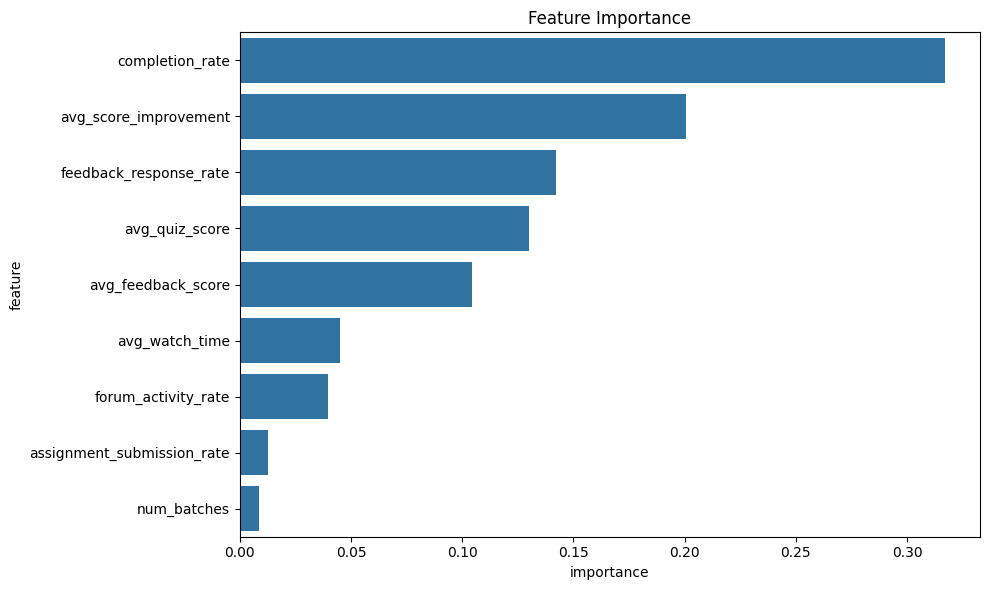

In [81]:
feature_importance = pd.DataFrame({
    'feature'   : features,
    'importance': rfc.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

### Q1.Which features most influenced instructor effectiveness, and why?

#### 1. completion_rate --> essential feature 
        The instructor whose students complete the course is clearly effective.

2. avg_score_improvement -->
        Because this directly measures how much students 
   actually learned from the instructor.
   
4. avg_quiz_score --> Quize score is  reality , students are understood the concepts or  not.

5. avg_feedback_score --> Because student satisfaction reflects teaching quality.

 

### Q2.Which variables could be misleading or confounded?

#### 1.completion_rate --> A high completion rate may show the easy course instead of instructor effectiveness.

2. avg_feedback_score --> Students may rate higher of popular or 
   friendly instructors rather than of learning.

3. completion_rate and dropout_rate together — Both 
   represent same information in opposite directions, 
   using both would cause multicollinearity.

### Q3.How could this model fail in real-world usage?

#### 
1. Course difficulty bias --> if an instructor teaching a tough course , then naturally students complition rate will be low and even score. then model will say ineffective, but reality is , course was tough , not an instructor.

2. small size --> those instructor who have taught only 7-8 batches, whose rating is not reliable . judgment is wrong on the less no. of data.

3. Concept drift --> the model trained on old dataset . what if change teaching trends , like after COVID whole education trends was changed.

### Q4. What additional data would you want to improve this analysis?

####
1. Course difficulty rating --> if we have Course difficulty Rating column may more better out comes.

2.Instructor experience --> if know that ,the how many they have been teaching , they have also helps to measure.

### Q5. Should this model be used for instructor performance evaluation? Why or why not?


#### 
Why yes,
1. Manually evaluating 120 instructors is difficult—the model can do this at scale.

2. 92% accuracy – very reliable.

Why not :

1. The model doesn't understand context -->it doesn't consider factors like course difficulty and student background.

Use this model as a starting point—
Identify low-tier instructors and
provide them  mentoring and support.

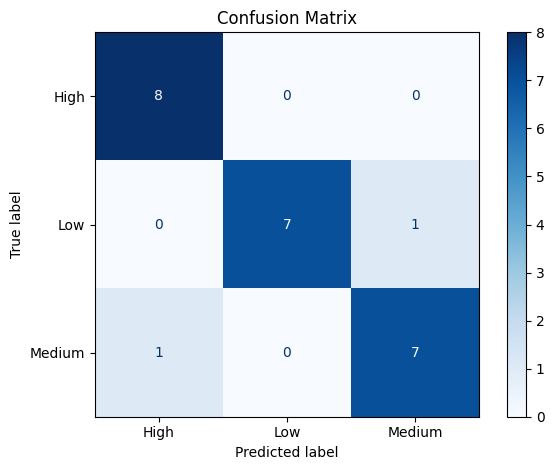

In [86]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=rfc.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()

plt.show()